# Data Exploration

For initial exploration / plotting of data

In [8]:
%pip install xeofs

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
## import modules
import time
import_start = time.time()

import xarray as xr
import numpy as np

from xeofs.single import EOF
from sklearn.decomposition import PCA

import matplotlib as mpl
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

print(f'Imports done in {time.time() - import_start:.2f}s')

Imports done in 3.45s


In [5]:
## import data

data = xr.open_dataset('./data/ACOD_CTD_v1.0.nc')

display(data)

<xarray.Dataset> Size: 1GB
Dimensions:                       (PROFILE: 29717, STRINGSHORT: 14,
                                   PRESSURE: 2201)
Coordinates:
  * PROFILE                       (PROFILE) int32 119kB 1 2 3 ... 29716 29717
    TIME                          (PROFILE) datetime64[ns] 238kB ...
    LONGITUDE                     (PROFILE) float32 119kB ...
    LATITUDE                      (PROFILE) float32 119kB ...
  * PRESSURE                      (PRESSURE) float32 9kB 0.0 1.0 ... 5e+03
Dimensions without coordinates: STRINGSHORT
Data variables:
    BOTTOM_DEPTH                  (PROFILE) float32 119kB ...
    REGION                        (STRINGSHORT, PROFILE) object 3MB ...
    CRUISE_NUMBER                 (PROFILE) float32 119kB ...
    CRUISE_NAME                   (STRINGSHORT, PROFILE) object 3MB ...
    CAST                          (PROFILE) float32 119kB ...
    Temperature                   (PRESSURE, PROFILE) float32 262MB ...
    Salinity_PPT                  (PRESSURE, PROFILE) float32 262MB ...
    Salinity_PPT_with_QC_applied  (PRESSURE, PROFILE) float32 262MB ...
    Salinity_PSS                  (PRESSURE, PROFILE) float32 262MB ...
    Salinity_PSS_with_QC_applied  (PRESSURE, PROFILE) float32 262MB ...
Attributes:
    title:                   CTD data from the Alaska Compendium of Ocean Pro...
    author:                  Noel A. Pelland, Shaun W. Bell, Calvin W. Mordy,...
    contact:                 mordy@uw.edu
    history:                 09/11/2025 15:28 Pacific (USA) Time, using MATLA...
    Conventions:             CF-1.8
    netcdf_version:          netCDF-4
    references:              Data: https://doi.org/10.5061/dryad.gf1vhhn0t  D...
    institution:             NOAA Pacific Marine Environmental Laboratory, Se...
    institution_references:  https://www.pmel.noaa.gov
    institution_country:     United States
    source:                  research vessel
    featureType:             profile

Plotting finished in 0.00s


Text(0, 0.5, 'Depth (m)')

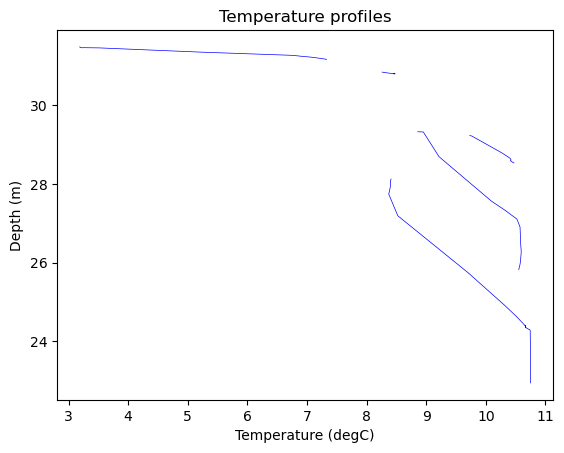

In [13]:
n_profiles = 5

temp_profiles = data.Temperature.values.transpose()[-n_profiles:]
salinity_profiles = data.Salinity_PSS_with_QC_applied.values.transpose()[-n_profiles:]

fig, ax = plt.subplots()#figsize=(4, 6))

depth = data.PRESSURE * -1 ## ~ depth

start_time = time.time()
'''for profile in temp_profiles:
    ax.plot(profile, depth, alpha=0.02, linewidth=0.2, color='red')'''

'''for profile in salinity_profiles:
    ax.plot(profile, depth, alpha=0.1, linewidth=0.2, color='red')'''

for i in range(n_profiles):
    ax.plot(temp_profiles[i], salinity_profiles[i], alpha=1, linewidth=0.5, color='blue')
    
print(f'Plotting finished in {time.time() - start_time:.2f}s')

ax.set_title('Temperature profiles')
ax.set_xlabel('Temperature (degC)')
ax.set_ylabel('Depth (m)')

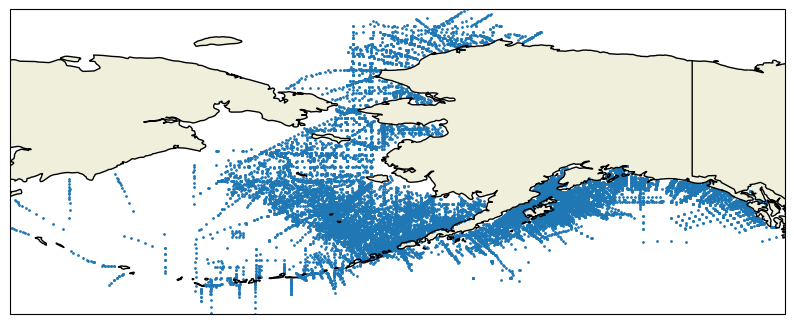

In [28]:
proj = ccrs.PlateCarree(central_longitude=180)

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={
    'projection': proj
})

lons = data.LONGITUDE
lats = data.LATITUDE

ext = (lons.data.min()+180, lons.data.max()+180, lats.data.min(), lats.data.max())

ax.set_extent(
    ext,
    crs = proj
)

ax.scatter(
    data.LONGITUDE+180, data.LATITUDE,
    s=1,
    transform = proj
)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)

plt.show()